In [16]:
import glob
from collections import OrderedDict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Report

In [17]:
runs = [
    "SRR19279042_SCANseq2_UMI200", 
    "SRR19279044_SCANseq2_UMI100", 
    "SRR19279045_SCANseq2_4CL", 
    "SRR19279047_SCANseq2_9CL"]

array = []

for run in runs:
    d = OrderedDict()
    
    total_reads = int(open("../results/1_prepare/3_read_count/%s.txt" % run).readlines()[0].strip())
    d["TotalReads"] = total_reads
    
    cell_reads = 0
    for path in glob.glob("../results/2_demux/4_pychopper/%s/*.log" % run):
        for line in open(path):
            if "Total fastq records in input file:" in line:
                cell_reads += int(line.strip().split()[-1])
    d["CellReads"] = cell_reads
    d["CellRatio"] = cell_reads / total_reads
    
    trim_reads = 0
    polya_reads = 0
    for path in glob.glob("../results/2_demux/5_trim_polya/%s/*.log" % run):
        lines = open(path).readlines()
        trim_reads += int(lines[0].strip().split()[-1])
        polya_reads += int(lines[1].strip().split()[-1])
    d["TrimReads"] = trim_reads
    d["TrimRatio"] = trim_reads / total_reads
    d["PolyAReads"] = polya_reads
    d["PolyARatio"] = polya_reads / total_reads
    
    mapped = 0
    for path in glob.glob("../results/3_mapping/1_minimap2/%s/*.flagstat" % run):
        with open(path) as f:
            for line in f:
                if "primary mapped" in line:
                    mapped += int(line.split()[0])
    d["MappedReads"] = mapped
    d["MappedRatio"] = mapped / total_reads
    
    filtered = 0
    for path in glob.glob("../results/3_mapping/2_filtered/%s/*.flagstat" % run):
        with open(path) as f:
            for line in f:
                if "primary mapped" in line:
                    filtered += int(line.split()[0])
    d["FilteredReads"] = filtered
    d["FilteredRatio"] = filtered / total_reads
    
    clip_filtered = 0
    for path in glob.glob("../results/3_mapping/3_stat_clip/%s/*.flagstat" % run):
        with open(path) as f:
            for line in f:
                if "primary mapped" in line:
                    clip_filtered += int(line.split()[0])
    d["ClipFilteredReads"] = clip_filtered
    d["ClipFilteredRatio"] = clip_filtered / total_reads
                    
    array.append(d)
    
d = pd.DataFrame(array, index=pd.Index(runs, name="Sample"))
d.to_csv("data_yield_of_scan_seq2.csv")
d

,TotalReads,CellReads,CellRatio,TrimReads,TrimRatio,PolyAReads,PolyARatio,MappedReads,MappedRatio,FilteredReads,FilteredRatio,ClipFilteredReads,ClipFilteredRatio
Sample,,,,,,,,,,,,,
SRR19279042_SCANseq2_UMI200,47419955,28084696,0.592255,25957346,0.547393,21040777,0.443711,20178005,0.425517,15998769,0.337385,10653909,0.224671
SRR19279044_SCANseq2_UMI100,47209842,32608563,0.690715,29457274,0.623965,23310764,0.493769,22472770,0.476019,17984507,0.380948,13231386,0.280268
SRR19279045_SCANseq2_4CL,84610428,68262224,0.806783,67678625,0.799885,56844439,0.671837,54487074,0.643976,45167972,0.533835,41991055,0.496287
SRR19279047_SCANseq2_9CL,84801426,61465620,0.724818,60694021,0.715719,48516936,0.572124,46230451,0.545161,36456546,0.429905,32887799,0.387821


# Plot

TotalRatio       100.000000
CellRatio         70.364276
TrimRatio         67.174052
PolyARatio        54.536048
MappedRatio       52.266826
FilteredRatio     42.051811
dtype: float64
TotalRatio        0.000000
CellRatio         8.880809
TrimRatio        10.969662
PolyARatio        9.951023
MappedRatio       9.457974
FilteredRatio     8.447024
dtype: float64


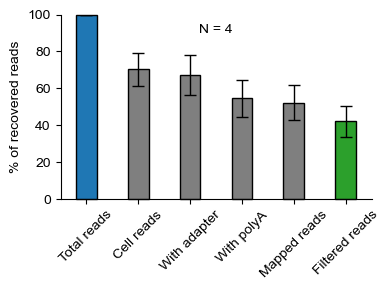

In [19]:
m = pd.read_csv("data_yield_of_scan_seq2.csv")
m = m[["CellRatio", "TrimRatio", "PolyARatio", "MappedRatio", "FilteredRatio", "ClipFilteredRatio"]].copy()
m["TotalRatio"] = 1
m = m[["TotalRatio", "CellRatio", "TrimRatio", "PolyARatio", "MappedRatio", "FilteredRatio"]] * 100

ys = m.mean()
yerr = m.std()
xs = np.arange(len(ys))
colors = ["C0", "C7", "C7", "C7", "C7", "C2"]
ticks = ["Total reads", "Cell reads", "With adapter", "With polyA", "Mapped reads", "Filtered reads"]
print(ys)
print(yerr)

plt.figure(figsize=(4, 3))
plt.bar(xs, ys, yerr=yerr, edgecolor="black", color=colors, width=0.4,
        error_kw={"capsize": 4, "linewidth": 1}, clip_on=False)
plt.text(2.5, 90, "N = 4", ha="center")
plt.xlim(-0.5, 5.5)
plt.xticks(xs, ticks, rotation=45)
plt.ylim(0, 100)
plt.ylabel("% of recovered reads")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("data_yield_of_scan_seq2.pdf")